In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pickle

Load dataset

In [38]:
df = pd.read_csv('https://raw.githubusercontent.com/Phub811/Customer-Churn-Clustering/refs/heads/main/Raw%20dataset/Dataset_ATS_v2.csv')

df.columns = df.columns.str.strip().str.lower()
df_original = df.copy()
df.head()

,gender,seniorcitizen,dependents,tenure,phoneservice,multiplelines,internetservice,contract,monthlycharges,churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


Explore dataset

In [39]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   seniorcitizen    7043 non-null   int64 
 2   dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   phoneservice     7043 non-null   object
 5   multiplelines    7043 non-null   object
 6   internetservice  7043 non-null   object
 7   contract         7043 non-null   object
 8   monthlycharges   7043 non-null   int64 
 9   churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


,0
gender,0
seniorcitizen,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
contract,0
monthlycharges,0
churn,0


Keep original data set

In [40]:
#df_original = df.copy()

Drop unnecessary columns for clustering and encode

In [41]:
cols_to_drop = []

if 'customerid' in df.columns:
    cols_to_drop.append('customerid')

if 'churn' in df.columns:
    cols_to_drop.append('churn')

df = df.drop(cols_to_drop, axis=1)

df = pd.get_dummies(df, drop_first=True)

In [42]:
print(df.head())

   seniorcitizen  tenure  monthlycharges  gender_Male  dependents_Yes  phoneservice_Yes  multiplelines_Yes  internetservice_Fiber optic  contract_One year  contract_Two year
0              0       1              25        False           False             False              False                        False              False              False
1              0      41              25         True           False              True              False                        False               True              False
2              0      52              19        False            True              True              False                        False              False              False
3              0       1              76        False           False              True              False                        False               True              False
4              0      67              51         True           False              True              False                        

Save preprocessed dataset

In [43]:
from google.colab import drive
drive.mount('/content/drive')
import os
base_path = "/content/drive/MyDrive/Customer-Churn-Clustering"
os.makedirs(base_path + "/Data_Preparation", exist_ok=True)
df.to_csv(base_path + "/Data_Preparation/preprocessed_dataset.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train/Test Split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

Save RAW Train/Test Data

In [45]:
import os
base_path = "/content/drive/MyDrive/Customer-Churn-Clustering"

# Create full folder path
os.makedirs(base_path + "/Data_Preparation/train_test_sets", exist_ok=True)
X_train.to_csv(base_path + "/Data_Preparation/train_test_sets/X_train_raw.csv", index=False)
X_test.to_csv(base_path + "/Data_Preparation/train_test_sets/X_test_raw.csv", index=False)

Scale the data

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
df.head()

,seniorcitizen,tenure,monthlycharges,gender_Male,dependents_Yes,phoneservice_Yes,multiplelines_Yes,internetservice_Fiber optic,contract_One year,contract_Two year
0,0,1,25,False,False,False,False,False,False,False
1,0,41,25,True,False,True,False,False,True,False
2,0,52,19,False,True,True,False,False,False,False
3,0,1,76,False,False,True,False,False,True,False
4,0,67,51,True,False,True,False,True,False,False


Save scaled data

In [47]:
X_train_scaled.to_csv(base_path + "/Data_Preparation/train_test_sets/X_train_scaled.csv", index=False)
X_test_scaled.to_csv(base_path + "/Data_Preparation/train_test_sets/X_test_scaled.csv", index=False)

Clustering
Elbow Method

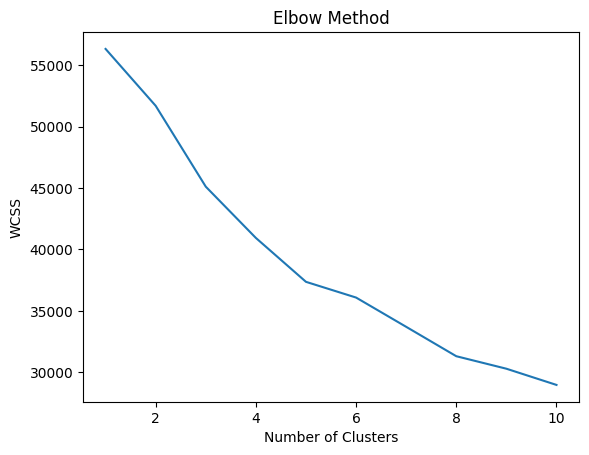

In [48]:
import os
import matplotlib.pyplot as plt
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
os.makedirs(base_path + "/Clustering_Analysis", exist_ok=True)
plt.savefig(base_path + "/Clustering_Analysis/elbow_method.png")
plt.show()

Train Final Model- Apply kmeans

In [49]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_train_scaled)

KMeans(n_clusters=4, random_state=42)

save Model

In [50]:
with open(base_path + "/Clustering_Analysis/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

Scale full data set

In [51]:
df_scaled_full = scaler.transform(df)
df_scaled_full = pd.DataFrame(df_scaled_full, columns=df.columns, index=df.index)

 ADD CLUSTERS TO ORIGINAL DATA

In [52]:
df_original['Cluster'] = kmeans.predict(df_scaled_full)

Check missing Values

In [53]:
print("Missing cluster values:", df_original['Cluster'].isnull().sum())

Missing cluster values: 0


Churn Analysis

Cluster Summary

In [54]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

cluster_summary = df_original.groupby('Cluster').mean(numeric_only=True)

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         seniorcitizen     tenure  monthlycharges
Cluster                                          
0             0.154572  32.506195       65.526254
1             0.163137  31.927304       65.625072
2             0.180584  32.224711       63.443313
3             0.154605  32.729323       64.346805


Save Cluster summary

In [55]:
cluster_summary.to_csv(base_path + "/Clustering_Analysis/cluster_summary.csv")

Cluster Visualization

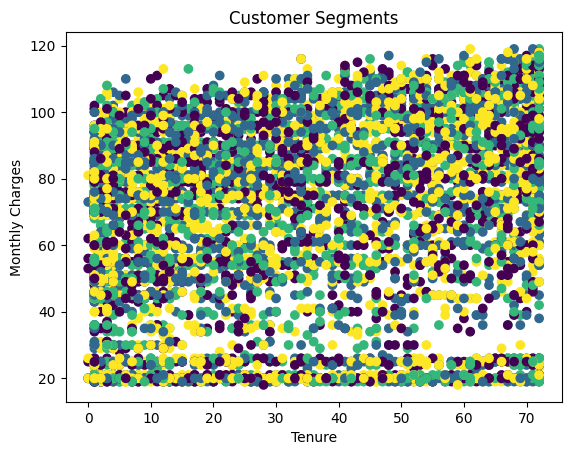

In [56]:
plt.figure()
plt.scatter(df_original['tenure'], df_original['monthlycharges'],
            c=df_original['Cluster'])
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.title('Customer Segments')

plt.savefig(base_path + "/Clustering_Analysis/clusters.png")
plt.show()

Churn by Cluster

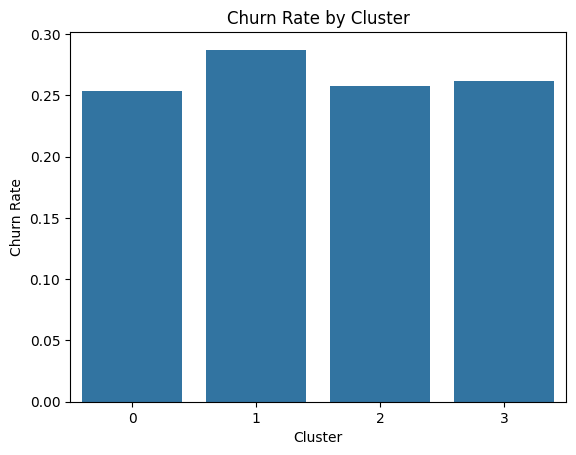

In [57]:
if 'churn' in df_original.columns:
    df_original['churn'] = df_original['churn'].astype(str).str.strip().str.lower()
    df_original['churn'] = df_original['churn'].map({'yes': 1, 'no': 0})

    churn_rate = df_original.groupby('Cluster')['churn'].mean()

    plt.figure()
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.xlabel('Cluster')
    plt.ylabel('Churn Rate')
    plt.title('Churn Rate by Cluster')
    plt.savefig(base_path + "/Clustering_Analysis/churn_by_cluster.png")
    plt.show()

In [58]:
df_original.to_csv(base_path + "/Clustering_Analysis/processed_data_with_clusters.csv", index=False)